# Imbalance, the newsvendor and quantile decisions

A retailer buys volume `q` for each hour in the day-ahead (DA) market. Actual load `L` is
uncertain. Shortfall is bought at the system **buy** imbalance price (above DA); surplus is
sold at the system **sell** price (below DA). How much should you buy, and how do you know
your forecast is good *for that decision*?

**What's in here**
- Synthetic imbalance prices with an asymmetric spread, and why asymmetry matters
- The newsvendor result: buy the quantile at the critical fractile, not the mean
- Brute-force verification for one hour; cost of using the mean forecast
- Quantile regression with sklearn (`QuantileRegressor`, GBM with quantile loss)
- Honest features: forecasts joined point-in-time with `merge_asof`, lags actually known at 12:00
- Calibration (coverage) and pinball loss — RMSE is the wrong metric for a quantile
- Decision evaluation in **money**: point forecast vs safety margin vs quantile vs perfect foresight
- How the optimal fractile moves when the spread asymmetry changes
- Value of information: actual vs forecast vs no temperature, in €

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
fc = pd.read_csv("../data/weather_forecasts.csv", parse_dates=["origin_datetime", "forecast_datetime"])

SHARE = 0.05                      # pretend we are a retailer with 5% of national load
df["load_mwh"] = df["consumption_mwh"] * SHARE
df[["time", "load_mwh", "temp_c", "price_eur_mwh"]].head(3)

,time,load_mwh,temp_c,price_eur_mwh
0,2022-01-01 00:00:00+00:00,1342.92,0.11,81.83
1,2022-01-01 01:00:00+00:00,1308.89,-0.18,88.21
2,2022-01-01 02:00:00+00:00,1311.47,-1.11,84.71


## 1. Imbalance prices (synthetic)

The real data has only a day-ahead price. Build a system-buy price `DA + premium_buy` and a
system-sell price `DA − premium_sell`, both premiums log-normal so they are always positive
and occasionally large. The **buy premium is larger on average** than the sell premium:
being short is more expensive than being long. That asymmetry drives everything below.

In [2]:
prem_buy = rng.lognormal(mean=np.log(25), sigma=0.6, size=len(df))
prem_sell = rng.lognormal(mean=np.log(12), sigma=0.6, size=len(df))
df["p_da"] = df["price_eur_mwh"]
df["p_buy"] = df["p_da"] + prem_buy
df["p_sell"] = df["p_da"] - prem_sell

print("mean buy premium :", prem_buy.mean().round(1), "€/MWh")
print("mean sell premium:", prem_sell.mean().round(1), "€/MWh")
df[["p_da", "p_buy", "p_sell"]].describe().round(1).loc[["mean", "std", "min", "50%", "max"]]

mean buy premium : 29.9 €/MWh
mean sell premium: 14.5 €/MWh


,p_da,p_buy,p_sell
mean,98.5,128.4,84.0
std,36.9,41.8,38.1
min,-19.9,-6.3,-71.4
50%,97.7,126.5,83.5
max,419.6,452.1,409.3


### The cost of a decision

For one hour, having bought `q` and consumed `L`:

`cost(q) = q · p_da + max(L − q, 0) · p_buy − max(q − L, 0) · p_sell`

Rearranged relative to the perfect-foresight cost `L · p_da`:

`excess(q) = c_u · max(L − q, 0) + c_o · max(q − L, 0)`, with
`c_u = p_buy − p_da` (cost per MWh of being **under**) and `c_o = p_da − p_sell` (cost of being **over**).

Everything is linear in volume, so the whole problem is the classic **newsvendor**.

In [3]:
def imbalance_cost(q, L, p_da, p_buy, p_sell):
    short = np.clip(L - q, 0, None)
    surplus = np.clip(q - L, 0, None)
    return q * p_da + short * p_buy - surplus * p_sell

def excess_cost(q, L, p_da, p_buy, p_sell):
    return imbalance_cost(q, L, p_da, p_buy, p_sell) - L * p_da

## 2. The newsvendor result

Minimising `E[c_u · (L − q)⁺ + c_o · (q − L)⁺]` over `q` gives the first-order condition
`P(L ≤ q*) = c_u / (c_u + c_o)`. So the optimal purchase is the **quantile of the load
distribution at the critical fractile** `τ* = c_u / (c_u + c_o)`.

- Under-cost bigger than over-cost → `τ* > 0.5` → buy *more* than the median.
- Symmetric costs → `τ* = 0.5` → buy the median (≈ the mean for a symmetric distribution).

Verify by brute force for one hour with a normal load distribution.

critical fractile tau* = 0.676
q* brute force = 1533   q* = quantile(tau*) = 1533   mean = 1500
expected excess cost: at q*: 1000 €   at the mean: 1103 €   (+10.3%)


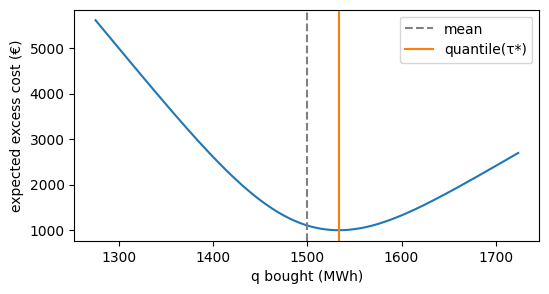

In [4]:
mu, sd = 1500.0, 75.0                  # one hour's load forecast: mean and uncertainty (MWh)
c_u, c_o = 25.0, 12.0                  # €/MWh
L_sims = rng.normal(mu, sd, 50_000)

grid = np.arange(mu - 3 * sd, mu + 3 * sd, 1.0)
exp_cost = np.array([np.mean(c_u * np.clip(L_sims - q, 0, None) + c_o * np.clip(q - L_sims, 0, None)) for q in grid])

tau_star = c_u / (c_u + c_o)
q_brute = grid[np.argmin(exp_cost)]
q_formula = np.quantile(L_sims, tau_star)
q_mean = mu

print(f"critical fractile tau* = {tau_star:.3f}")
print(f"q* brute force = {q_brute:.0f}   q* = quantile(tau*) = {q_formula:.0f}   mean = {q_mean:.0f}")
cost_at = lambda q: exp_cost[np.argmin(np.abs(grid - q))]
print(f"expected excess cost: at q*: {cost_at(q_formula):.0f} €   at the mean: {cost_at(q_mean):.0f} €   "
      f"(+{cost_at(q_mean)/cost_at(q_formula)-1:.1%})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(grid, exp_cost); ax.axvline(q_mean, ls="--", c="grey", label="mean"); ax.axvline(q_formula, c="C1", label="quantile(τ*)")
ax.set_xlabel("q bought (MWh)"); ax.set_ylabel("expected excess cost (€)"); ax.legend(); plt.show()

**Interview check:** "Your forecast is unbiased. Why would you deliberately buy more than
you expect to use?" — Because the loss is asymmetric. The unbiased point forecast minimises
squared error, not cost. The decision needs a quantile, and which quantile depends on prices.

**Pitfall:** swap `c_u` and `c_o` and you get `τ* = 0.32` — you would systematically
under-buy and pay the expensive side. Write the definitions down before coding.

## 3. Honest features for a day-ahead decision

The decision for every hour of day **D** is made at **12:00 on D−1** (the DA auction). At
that moment you know:
- load up to 11:00 on D−1 → the "same hour yesterday" lag (24h) is **not** known for hours
  after 12:00; use lags of 48h and 168h, which are fully known;
- weather **forecasts** issued at or before 12:00 D−1, not actual temperature.

Join forecasts with `merge_asof`: for each target hour, the latest origin ≤ decision time.

In [5]:
df["decision_time"] = df["time"].dt.floor("D") - pd.Timedelta(hours=12)     # 12:00 on D-1

fc_ren = fc.rename(columns={"forecast_datetime": "time"}).sort_values("origin_datetime")
m = pd.merge_asof(df.sort_values("decision_time"), fc_ren,
                  left_on="decision_time", right_on="origin_datetime",
                  by="time", direction="backward")
m = m.sort_values("time").reset_index(drop=True)

ok = m.dropna(subset=["origin_datetime"])
print("rows without a forecast (first day):", m["origin_datetime"].isna().sum())
print("all forecasts issued at or before decision time:", bool((ok["origin_datetime"] <= ok["decision_time"]).all()))
print("forecast horizons used:", int(ok["horizon_h"].min()), "to", int(ok["horizon_h"].max()), "hours")
m[["time", "decision_time", "origin_datetime", "horizon_h", "temp_c", "temp_forecast_c"]].iloc[[30, 36, 47]]

rows without a forecast (first day): 24
all forecasts issued at or before decision time: True
forecast horizons used: 12 to 35 hours


,time,decision_time,origin_datetime,horizon_h,temp_c,temp_forecast_c
30,2022-01-02 06:00:00+00:00,2022-01-01 12:00:00+00:00,2022-01-01 12:00:00+00:00,18.0,0.73,1.85
36,2022-01-02 12:00:00+00:00,2022-01-01 12:00:00+00:00,2022-01-01 12:00:00+00:00,24.0,6.04,5.24
47,2022-01-02 23:00:00+00:00,2022-01-01 12:00:00+00:00,2022-01-01 12:00:00+00:00,35.0,2.57,1.48


In [6]:
m["hour"] = m["time"].dt.hour
m["is_weekend"] = (m["time"].dt.dayofweek >= 5).astype(int)
m["lag48"] = m["load_mwh"].shift(48)
m["lag168"] = m["load_mwh"].shift(168)
m["hdd_fc"] = np.clip(15 - m["temp_forecast_c"], 0, None)
m["cdd_fc"] = np.clip(m["temp_forecast_c"] - 22, 0, None)
m["hdd_act"] = np.clip(15 - m["temp_c"], 0, None)          # actual temperature: for the "cheating" comparison only
m["cdd_act"] = np.clip(m["temp_c"] - 22, 0, None)

hour_dummies = pd.get_dummies(m["hour"], prefix="h").astype(float)
m = pd.concat([m, hour_dummies], axis=1)
HCOLS = list(hour_dummies.columns)

FEATS = ["lag48", "lag168", "is_weekend", "hdd_fc", "cdd_fc"] + HCOLS
data = m.dropna(subset=FEATS + ["load_mwh"]).reset_index(drop=True)

train = data[data["time"] < "2023-07-01"]
test = data[data["time"] >= "2023-07-01"]
y = "load_mwh"
print("train rows:", len(train), " test rows:", len(test))

train rows: 12936  test rows: 4416


**Pitfall:** `shift(24)` "same hour yesterday" is the most natural lag and it is a leak for
a 12:00 D−1 decision for every hour after 12:00. Ask *when* each feature is known, not
whether it is in the past.

## 4. Quantile regression

`QuantileRegressor(quantile=τ, alpha=0, solver="highs")` minimises the pinball loss and
returns the conditional τ-quantile. `alpha=0` means no L1 penalty (the default `alpha=1`
shrinks hard and is rarely what you want). Fit τ = 0.1, 0.5, 0.9 and a point (OLS) model.

In [7]:
def fit_q(tau, feats, tr=train):
    return QuantileRegressor(quantile=tau, alpha=0, solver="highs").fit(tr[feats], tr[y])

qmodels = {tau: fit_q(tau, FEATS) for tau in (0.1, 0.5, 0.9)}
qpred = {tau: mdl.predict(test[FEATS]) for tau, mdl in qmodels.items()}

ols = LinearRegression().fit(train[FEATS], train[y])
pt_test = ols.predict(test[FEATS])
pt_train = ols.predict(train[FEATS])

pd.DataFrame({"actual": test[y].values, "q10": qpred[0.1], "q50": qpred[0.5], "q90": qpred[0.9], "ols": pt_test},
             index=test["time"]).head(6).round(0)

,actual,q10,q50,q90,ols
time,,,,,
2023-07-01 00:00:00+00:00,1042.0,1010.0,1065.0,1108.0,1062.0
2023-07-01 01:00:00+00:00,956.0,950.0,1006.0,1053.0,1003.0
2023-07-01 02:00:00+00:00,926.0,923.0,976.0,1028.0,976.0
2023-07-01 03:00:00+00:00,917.0,922.0,970.0,1021.0,971.0
2023-07-01 04:00:00+00:00,964.0,930.0,981.0,1036.0,981.0
2023-07-01 05:00:00+00:00,995.0,988.0,1040.0,1092.0,1041.0


### Calibration: does the τ-quantile cover τ of the test outcomes?

The one check that matters for a quantile forecast. Compute it **out of sample**, overall
and by hour of day (a quantile can be calibrated on average and badly wrong at 18:00).

In [8]:
cov = {tau: (test[y].values <= qpred[tau]).mean() for tau in qpred}
print("overall coverage:", {k: round(v, 3) for k, v in cov.items()})

cov_by_hour = pd.DataFrame({f"q{int(tau*100)}": (test[y].values <= qpred[tau]) for tau in qpred}, index=test["hour"].values)
cov_by_hour.groupby(level=0).mean().round(2).T

overall coverage: {0.1: 0.111, 0.5: 0.537, 0.9: 0.922}


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
q10,0.14,0.08,0.08,0.09,0.11,0.09,0.10,0.12,0.11,0.11,0.12,0.16,0.13,0.09,0.08,0.10,0.10,0.10,0.12,0.11,0.14,0.14,0.10,0.14
q50,0.60,0.57,0.60,0.57,0.58,0.53,0.51,0.51,0.57,0.51,0.55,0.58,0.51,0.49,0.52,0.53,0.55,0.49,0.52,0.46,0.57,0.51,0.55,0.52
q90,0.90,0.92,0.95,0.92,0.93,0.90,0.93,0.91,0.92,0.93,0.92,0.90,0.95,0.91,0.89,0.92,0.92,0.91,0.92,0.93,0.93,0.93,0.92,0.95


### Pinball loss, not RMSE

The pinball (quantile) loss `ρ_τ(e) = max(τ·e, (τ−1)·e)` with `e = actual − prediction` is
what a τ-quantile minimises. RMSE ranks the 0.9-quantile as "worse" than the median because
it is biased upwards **on purpose**.

In [9]:
def pinball(y_true, y_pred, tau):
    e = y_true - y_pred
    return np.mean(np.maximum(tau * e, (tau - 1) * e))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

rows = []
for name, pred in [("q10", qpred[0.1]), ("q50", qpred[0.5]), ("q90", qpred[0.9]), ("ols", pt_test)]:
    rows.append([name, rmse(test[y].values, pred), pinball(test[y].values, pred, 0.1),
                 pinball(test[y].values, pred, 0.5), pinball(test[y].values, pred, 0.9)])
pd.DataFrame(rows, columns=["model", "rmse", "pinball_0.1", "pinball_0.5", "pinball_0.9"]).round(1)

,model,rmse,pinball_0.1,pinball_0.5,pinball_0.9
0,q10,69.0,7.7,28.9,50.1
1,q50,44.5,19.2,17.5,15.9
2,q90,77.1,58.0,32.9,7.9
3,ols,44.5,19.3,17.5,15.8


Each quantile model wins its own column; OLS and q50 tie on RMSE. Judge a forecast by the
loss the decision actually has.

**Pitfall — crossing quantiles:** separately fitted quantiles can cross (q90 < q50 for some
rows). Check it; sort the predictions row-wise or use a monotone model if it matters.

In [10]:
crossing = ((qpred[0.9] < qpred[0.5]) | (qpred[0.5] < qpred[0.1])).mean()
print(f"rows with crossing quantiles: {crossing:.2%}")

# a non-linear alternative: gradient boosting with quantile loss (small, fast)
gbr90 = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=150, max_depth=3, random_state=0).fit(train[FEATS], train[y])
g90 = gbr90.predict(test[FEATS])
print(f"GBM q90 coverage: {(test[y].values <= g90).mean():.3f}   pinball_0.9: {pinball(test[y].values, g90, 0.9):.1f}"
      f"   (linear QR: {pinball(test[y].values, qpred[0.9], 0.9):.1f})")

rows with crossing quantiles: 0.00%


GBM q90 coverage: 0.897   pinball_0.9: 9.4   (linear QR: 7.9)


## 5. Evaluate decisions in money

Four purchasing policies on the test period:
1. **point**: buy the OLS forecast;
2. **point + margin**: add a fixed safety margin, tuned on the *train* period;
3. **quantile at τ\***: buy the quantile-regression forecast at the critical fractile, τ\*
   estimated from the *train* period's average premiums;
4. **perfect foresight**: buy exactly `L` — the unattainable lower bound.

Compare total cost and excess cost per MWh over perfect foresight.

In [11]:
L, PDA, PB, PS = (test[c].values for c in [y, "p_da", "p_buy", "p_sell"])
Ltr, PDAtr, PBtr, PStr = (train[c].values for c in [y, "p_da", "p_buy", "p_sell"])

# critical fractile from the train period only
cu_tr = (train["p_buy"] - train["p_da"]).mean()
co_tr = (train["p_da"] - train["p_sell"]).mean()
tau_star = cu_tr / (cu_tr + co_tr)
print(f"train: c_u = {cu_tr:.1f}, c_o = {co_tr:.1f}  →  tau* = {tau_star:.3f}")

# safety margin tuned on train
margins = np.arange(-100, 150, 5.0)
train_costs = [excess_cost(pt_train + mg, Ltr, PDAtr, PBtr, PStr).sum() for mg in margins]
best_margin = margins[int(np.argmin(train_costs))]
print(f"best fixed margin on train: {best_margin:+.0f} MWh")

q_tau = fit_q(tau_star, FEATS).predict(test[FEATS])

policies = {
    "point (OLS)":              pt_test,
    "point + margin (train)":   pt_test + best_margin,
    f"quantile @ tau*={tau_star:.2f}": q_tau,
    "perfect foresight":        L,
}
perfect = imbalance_cost(L, L, PDA, PB, PS).sum()
rows = []
for name, q in policies.items():
    tot = imbalance_cost(q, L, PDA, PB, PS).sum()
    rows.append([name, tot / 1e6, (tot - perfect) / 1e6, (tot - perfect) / L.sum(),
                 np.mean(q > L)])
res = pd.DataFrame(rows, columns=["policy", "total cost (M€)", "excess vs perfect (M€)", "excess €/MWh", "share of hours long"])
res.round(3)

train: c_u = 29.8, c_o = 14.6  →  tau* = 0.671
best fixed margin on train: +20 MWh


,policy,total cost (M€),excess vs perfect (M€),excess €/MWh,share of hours long
0,point (OLS),524.110,3.343,0.529,0.540
1,point + margin (train),523.915,3.147,0.498,0.716
2,quantile @ tau*=0.67,523.912,3.144,0.498,0.708
3,perfect foresight,520.767,0.000,0.000,0.000


The quantile policy and the tuned margin both beat the raw point forecast, and land close
to each other: with a roughly constant forecast-error distribution a fixed margin *is* an
approximate quantile. The quantile model earns its keep when uncertainty varies with the
features (cold snaps, weekends) — check the excess cost by hour.

**Interview check:** "You tuned the margin on the test set, right?" — No, on train. Tuning
a margin on the period you report is the same leak as tuning a hyperparameter on the test set.

In [12]:
ex_point = excess_cost(pt_test, L, PDA, PB, PS)
ex_q = excess_cost(q_tau, L, PDA, PB, PS)
by_hour = pd.DataFrame({"point": ex_point, "quantile": ex_q}, index=test["hour"].values).groupby(level=0).sum() / 1e3
by_hour["saving_k€"] = by_hour["point"] - by_hour["quantile"]
by_hour.round(0).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
point,128.0,139.0,121.0,111.0,114.0,132.0,128.0,139.0,136.0,143.0,133.0,133.0,112.0,148.0,148.0,136.0,132.0,147.0,151.0,164.0,161.0,164.0,171.0,152.0
quantile,126.0,125.0,120.0,112.0,117.0,129.0,121.0,133.0,132.0,133.0,127.0,131.0,106.0,134.0,138.0,124.0,130.0,135.0,132.0,145.0,151.0,145.0,155.0,144.0
saving_k€,2.0,14.0,2.0,-1.0,-3.0,3.0,7.0,6.0,4.0,10.0,6.0,2.0,6.0,15.0,10.0,12.0,2.0,12.0,19.0,19.0,10.0,19.0,16.0,8.0


## 6. The fractile moves with the market

If the sell premium becomes the larger one (e.g. a market that punishes being long), `τ*`
drops below 0.5 and you should buy *less* than the median. Recompute the optimal policy for a
few asymmetry settings, keeping the same forecast models.

In [13]:
rows = []
for cu_, co_ in [(25, 12), (18, 18), (12, 25), (40, 8)]:
    tau = cu_ / (cu_ + co_)
    q = fit_q(tau, FEATS).predict(test[FEATS])
    pb_, ps_ = PDA + cu_, PDA - co_                      # deterministic premiums for this illustration
    ex_q_ = excess_cost(q, L, PDA, pb_, ps_).sum()
    ex_pt = excess_cost(pt_test, L, PDA, pb_, ps_).sum()
    rows.append([cu_, co_, tau, ex_pt / 1e6, ex_q_ / 1e6, 1 - ex_q_ / ex_pt])
pd.DataFrame(rows, columns=["c_u", "c_o", "tau*", "excess: point (M€)", "excess: quantile (M€)", "saving"]).round(3)

,c_u,c_o,tau*,excess: point (M€),excess: quantile (M€),saving
0,25,12,0.676,2.738,2.597,0.052
1,18,18,0.500,2.785,2.789,-0.001
2,12,25,0.324,2.988,2.583,0.136
3,40,8,0.833,3.406,2.359,0.307


Symmetric costs: the quantile policy is the median and saves almost nothing over the point
forecast. The more asymmetric the market, the more a quantile decision is worth.

## 7. Value of information

How much is a better weather input worth, in €? Same decision rule, three feature sets:
actual temperature at the target hour (impossible — a ceiling), the honest forecast, and
no temperature at all.

In [14]:
variants = {
    "actual temperature (cheating ceiling)": ["lag48", "lag168", "is_weekend", "hdd_act", "cdd_act"] + HCOLS,
    "forecast temperature (honest)":         FEATS,
    "no temperature":                        ["lag48", "lag168", "is_weekend"] + HCOLS,
}
rows = []
for name, feats in variants.items():
    q = fit_q(tau_star, feats).predict(test[feats])
    ex = excess_cost(q, L, PDA, PB, PS).sum()
    rows.append([name, ex / 1e6, rmse(L, q)])
voi = pd.DataFrame(rows, columns=["features", "excess cost (M€, Jul-Dec 2023)", "rmse (MWh)"]).round(2)
voi

,features,"excess cost (M€, Jul-Dec 2023)",rmse (MWh)
0,actual temperature (cheating ceiling),2.70,43.84
1,forecast temperature (honest),3.14,50.30
2,no temperature,4.26,64.79


In [15]:
ex_no, ex_fc, ex_act = voi.iloc[2, 1], voi.iloc[1, 1], voi.iloc[0, 1]
print(f"value of the weather forecast:            {ex_no - ex_fc:.2f} M€ over the test half-year")
print(f"remaining value of a perfect temperature: {ex_fc - ex_act:.2f} M€  (upper bound on what a better forecast could add)")

value of the weather forecast:            1.12 M€ over the test half-year
remaining value of a perfect temperature: 0.44 M€  (upper bound on what a better forecast could add)


That last number is the budget: no forecasting vendor is worth more than the gap between the
honest forecast and the cheating ceiling. Express model improvements in € like this and the
conversation with a trading desk becomes very short.

**Interview check:** "Your RMSE improved by 3%. So what?" — Translate it: what did the
decision cost before and after, on the same test window, with the same prices?

## Quick reference

| Question | Answer |
|---|---|
| How much to buy under asymmetric imbalance costs | the quantile at `τ* = c_u / (c_u + c_o)`, `c_u` = cost of being short, `c_o` = cost of being long |
| Fit a conditional quantile | `QuantileRegressor(quantile=τ, alpha=0, solver="highs")`; `GradientBoostingRegressor(loss="quantile", alpha=τ)` |
| Is the quantile any good | coverage on test ≈ τ, overall **and** by hour; pinball loss, not RMSE |
| Which lags are legal for a 12:00 D−1 decision | 48h and 168h, not 24h; forecasts with origin ≤ decision time (`merge_asof`) |
| Safety margin vs quantile | a margin tuned on **train** is a crude quantile; use the model when uncertainty varies |
| Comparing models | realised cost in € on the same window and prices; perfect foresight as the floor |
| Value of a data source | cost without it − cost with it; the cheating version bounds what is left |